In [8]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from preprocessing.steps.html_removal import remove_html
from preprocessing.steps.lowercasing import lowercase
from preprocessing.steps.tokenization import tokenize
from preprocessing.steps.punctuation import remove_punctuation
from preprocessing.steps.stopwords import remove_stopwords
from preprocessing.steps.lemmatization import lemmatize

df = pd.read_csv('../data/IMDB Dataset.csv')
print(f"Dataset size: {len(df)}")

Dataset size: 50000


In [9]:
text = df['review'].apply(remove_html).apply(lowercase)
tokens_after_tokenization = text.apply(tokenize)
tokens_after_punctuation = tokens_after_tokenization.apply(remove_punctuation)
tokens_after_stopwords = tokens_after_punctuation.apply(remove_stopwords)
tokens_after_lemmatization = tokens_after_stopwords.apply(lemmatize)

print("Done!")

Done!


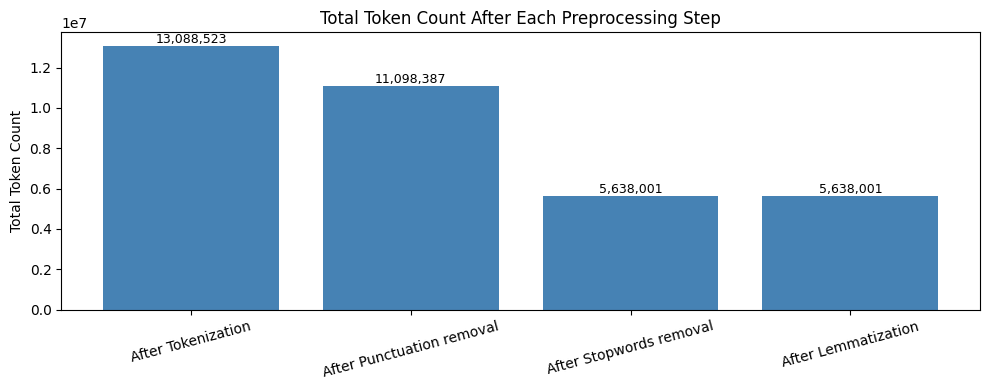

In [26]:
totals = {
    'After Tokenization': tokens_after_tokenization.apply(len).sum(),
    'After Punctuation removal': tokens_after_punctuation.apply(len).sum(),
    'After Stopwords removal': tokens_after_stopwords.apply(len).sum(),
    'After Lemmatization': tokens_after_lemmatization.apply(len).sum(),
}

plt.figure(figsize=(10, 4))
plt.bar(totals.keys(), totals.values(), color='steelblue')
plt.title('Total Token Count After Each Preprocessing Step')
plt.ylabel('Total Token Count')
plt.xticks(rotation=15)

# dodaj brojeve iznad stubica
for i, (step, count) in enumerate(totals.items()):
    plt.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
# Broj recenzija sa HTML tagovima
import re
has_html = df['review'].apply(lambda x: bool(re.search(r'<.*?>', x))).sum()
print(f"Reviews with HTML tags: {has_html} / {len(df)} ({has_html/len(df)*100:.1f}%)")

# Primer pre i posle HTML removal
example = df['review'][1]
print("\nBEFORE HTML removal:")
print(example[:300])
print("\nAFTER HTML removal:")
print(re.sub(r'<.*?>', '', example)[:300])

Reviews with HTML tags: 29202 / 50000 (58.4%)

BEFORE HTML removal:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

AFTER HTML removal:
A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voice


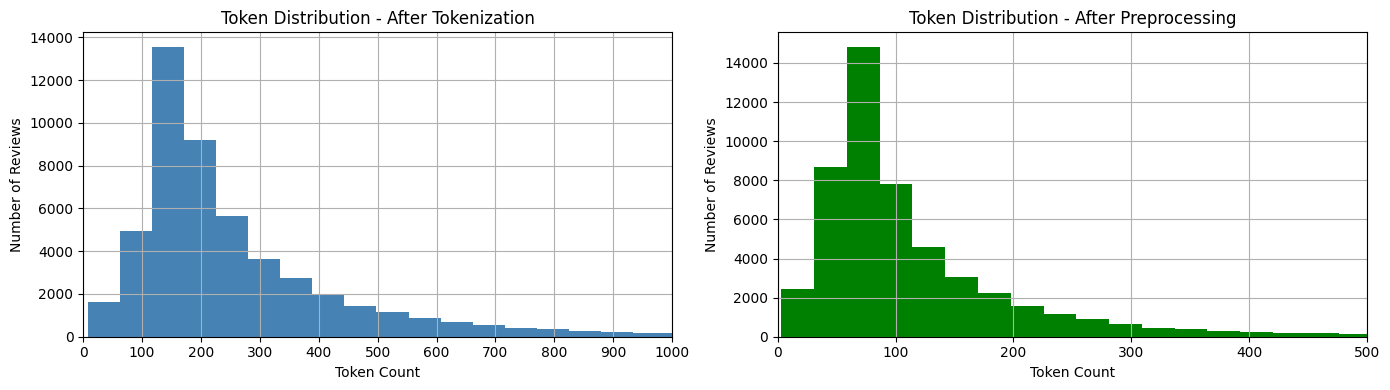

In [ ]:
#distribucija duzina recenzija pre i posle preprocessinga

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# pre punctuation/stopwords removala
tokens_after_tokenization.apply(len).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Token Distribution - After Tokenization')

# nakon preprocessinga
tokens_after_lemmatization.apply(len).hist(bins=50, ax=axes[1], color='green')
axes[1].set_title('Token Distribution - After Preprocessing')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Number of Reviews')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Number of Reviews')


# opcionooo
axes[0].set_xlim(0, 1000)
axes[1].set_xlim(0, 500)

axes[1].set_xlim(0, 300)
axes[1].set_xticks(range(0, 301, 50))

axes[0].set_xticks(range(0, 1001, 100))
axes[1].set_xticks(range(0, 501, 100))

plt.tight_layout()
plt.show()

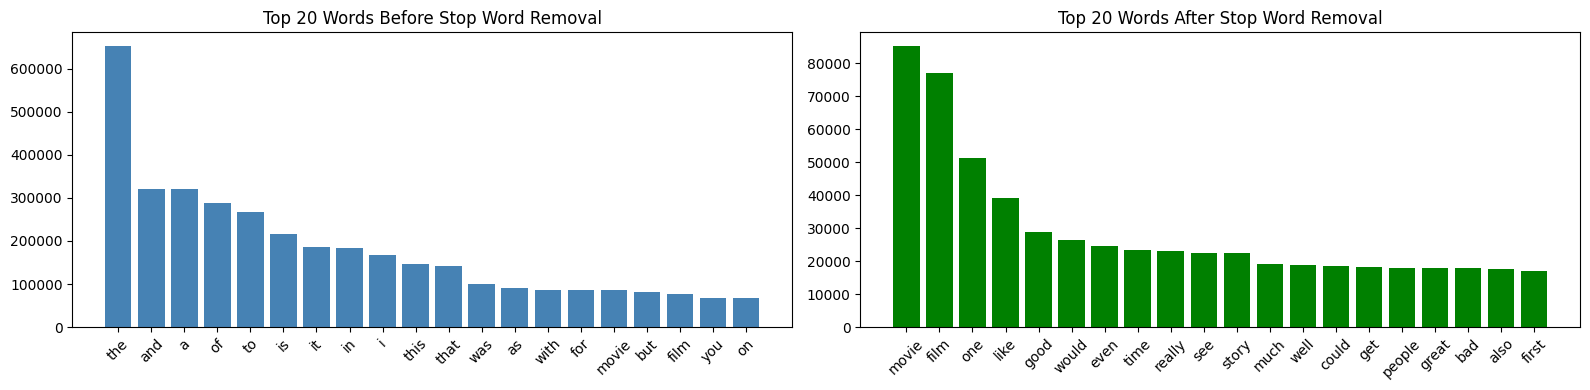

In [6]:
all_before = [t for tokens in tokens_after_punctuation for t in tokens]
all_after = [t for tokens in tokens_after_stopwords for t in tokens]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

words_before, counts_before = zip(*Counter(all_before).most_common(20))
ax1.bar(words_before, counts_before, color='steelblue')
ax1.set_title('Top 20 Words Before Stop Word Removal')
ax1.tick_params(axis='x', rotation=45)

words_after, counts_after = zip(*Counter(all_after).most_common(20))
ax2.bar(words_after, counts_after, color='green')
ax2.set_title('Top 20 Words After Stop Word Removal')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [37]:
changed = [(before, after) 
           for tokens_b, tokens_a in zip(tokens_after_stopwords, tokens_after_lemmatization)
           for before, after in zip(tokens_b, tokens_a)
           if before != after]

print(f"Total changed words: {len(changed)}")

from collections import Counter
changes_counter = Counter([(b, a) for b, a in changed])


print("\nMost common changes:")
for (before, after), count in changes_counter.most_common(10):
    print(f"  {before:20} → {after:20} ({count} times)")

# Podeli po tipu promene
print("\nMost common changes (excluding plurals):")
count = 0
for (before, after), n in changes_counter.most_common(100):
    # Preskoči ako je samo množina→jednina (završava se na 's')
    if not (before.endswith('s') and before[:-1] == after):
        print(f"  {before:20} → {after:20} ({n} times)")
        count += 1
    if count == 15:
        break

Total changed words: 594430

Most common changes:
  movies               → movie                (14760 times)
  characters           → character            (14153 times)
  films                → film                 (13455 times)
  scenes               → scene                (10201 times)
  actors               → actor                (8664 times)
  years                → year                 (8533 times)
  makes                → make                 (8281 times)
  us                   → u                    (7250 times)
  things               → thing                (7211 times)
  gets                 → get                  (6208 times)

Most common changes (excluding plurals):
  goes                 → go                   (4734 times)
  women                → woman                (3466 times)
  children             → child                (2993 times)
  lives                → life                 (2613 times)
  tries                → try                  (2420 times)
  stories          